In [37]:
# Step 1: Import Required Libraries

In [24]:
import pandas as pd
import numpy as np

In [25]:
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
# Step 2: Load the Dataset

In [26]:
# Load CSV file
df = pd.read_csv('dataset.csv', comment='#')

# Check Data
df.head()

,command,intent
0,open chrome,open_app
1,launch chrome,open_app
2,start google chrome,open_app
3,open the browser,open_app
4,i want to browse the web,open_app


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   command  138 non-null    object
 1    intent  138 non-null    object
dtypes: object(2)
memory usage: 2.3+ KB


In [29]:
# Remove null values
df.dropna(inplace=True)
# Remove duplicates
df.drop_duplicates(inplace=True)

df.shape


(138, 2)

In [30]:
# Step 4: Text Preprocessing Function

#Convert to lowercase
#Remove punctuation
#Remove numbers
#Remove extra spaces 

In [31]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text


In [32]:
df.columns

Index(['command', ' intent'], dtype='object')

In [33]:
df["clean_command"] = df["command"].apply(clean_text)
df.head()


,command,intent,clean_command
0,open chrome,open_app,open chrome
1,launch chrome,open_app,launch chrome
2,start google chrome,open_app,start google chrome
3,open the browser,open_app,open the browser
4,i want to browse the web,open_app,i want to browse the web


In [34]:
df.columns


Index(['command', ' intent', 'clean_command'], dtype='object')

In [35]:
df.columns = df.columns.str.strip().str.lower()
df.columns


Index(['command', 'intent', 'clean_command'], dtype='object')

In [39]:
# Step 5: Feature & Label Separation

In [36]:
X = df["clean_command"]
y = df["intent"]


In [40]:
# Step 6: Train-Test Split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (110,)
Testing samples: (28,)


In [42]:
# Step 7: Build NLP Pipeline (TF-IDF + SVM)

# This is the most important part for good accuracy

In [43]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        stop_words="english",
        max_df=0.95,
        min_df=2
    )),
    ("classifier", LinearSVC(C=1.5))
])


In [44]:
# Step 8: Train the Model

In [45]:
model.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [46]:
# Step 9: Model Evaluation 

In [47]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy


c:\Users\goyal\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


0.6428571428571429

In [48]:
df["intent"].value_counts()


intent
open_app              30
volume_control        14
youtube_search        13
brightness_control    10
time                   8
chat                   8
screenshot             7
shutdown               6
battery                6
spotify_play           6
vision                 6
restart                5
window_minimize        4
media_play             3
media_next             3
media_prev             3
system_lock            3
media_pause            3
Name: count, dtype: int64

In [49]:
df["intent"] = df["intent"].replace({
    "media_play": "media_control",
    "media_pause": "media_control",
    "media_next": "media_control",
    "media_prev": "media_control",
    "spotify_play": "media_control"
})


In [50]:
intent_counts = df["intent"].value_counts()
valid_intents = intent_counts[intent_counts >= 5].index
df = df[df["intent"].isin(valid_intents)]


In [51]:
X = df["clean_command"]
y = df["intent"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [52]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        stop_words="english",
        min_df=2
    )),
    ("clf", LinearSVC(
        C=2.0,
        class_weight="balanced"
    ))
])


In [53]:
model.fit(X_train, y_train)


,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [54]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)


0.7037037037037037

In [55]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "clf__C": [0.5, 1, 2, 3]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)


c:\Users\goyal\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


,estimator,Pipeline(step...'balanced'))])
,param_grid,"{'clf__C': [0.5, 1, ...], 'tfidf__ngram_range': [(1, ...), (1, ...)]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [56]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
accuracy_score(y_test, y_pred)


0.7777777777777778

In [64]:
df["intent"] = df["intent"].replace({
    "youtube_search": "media_control",
    "spotify_play": "media_control"
})


In [65]:
df["intent"].value_counts()


intent
media_control         31
open_app              30
volume_control        14
brightness_control    10
time                   8
chat                   8
screenshot             7
shutdown               6
battery                6
vision                 6
restart                5
Name: count, dtype: int64

In [66]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 3),   # ⬅️ BIG CHANGE
        stop_words="english",
        min_df=1,             # allow rare but useful words
        sublinear_tf=True
    )),
    ("clf", LinearSVC(
        C=3.0,
        class_weight="balanced"
    ))
])


In [67]:
model.fit(X_train, y_train)


,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [69]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)


0.7777777777777778

In [70]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

scores, scores.mean()


(array([0.88888889, 0.80769231, 0.80769231, 0.76923077, 0.65384615]),
 np.float64(0.7854700854700855))

In [71]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy


0.7777777777777778

In [72]:
print(classification_report(y_test, y_pred))


                    precision    recall  f1-score   support

           battery       0.00      0.00      0.00         1
brightness_control       0.00      0.00      0.00         2
              chat       0.67      1.00      0.80         2
     media_control       1.00      0.75      0.86         4
          open_app       1.00      1.00      1.00         6
           restart       1.00      1.00      1.00         1
        screenshot       0.00      0.00      0.00         1
          shutdown       0.00      0.00      0.00         1
              time       1.00      1.00      1.00         2
            vision       0.25      1.00      0.40         1
    volume_control       1.00      1.00      1.00         3
    youtube_search       0.75      1.00      0.86         3

          accuracy                           0.78        27
         macro avg       0.56      0.65      0.58        27
      weighted avg       0.73      0.78      0.74        27



c:\Users\goyal\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\goyal\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\goyal\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


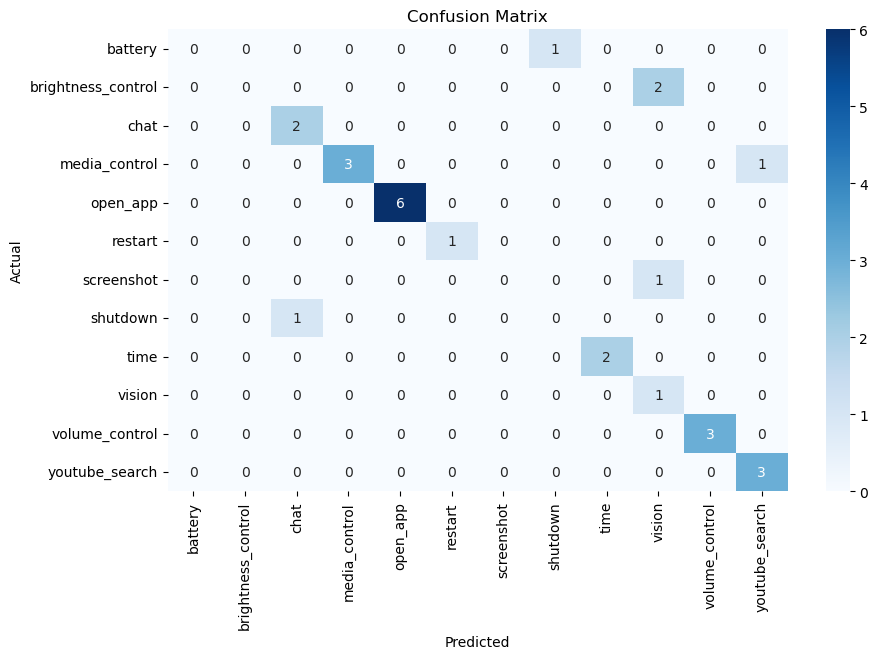

In [73]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [74]:
import joblib

joblib.dump(model, "intent_classification_model.pkl")


['intent_classification_model.pkl']

In [75]:
model = joblib.load("intent_classification_model.pkl")
